# Parameter calibration based on polarization test data — 0D model

This notebook calibrates the undetermined physical parameters of the Pukrushpan-style 0D PEMFC model (`PEMFC_0D`) by fitting the simulated cell voltage to experimental measurements across the same 12 operating conditions (temperature, pressure, humidity) used for the 1D static and dynamic notebooks.

In [1]:
import sys
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import optuna
from copy import deepcopy
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

In [2]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024"
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from config.settings import *
from model.dualscale import PEMFC_0D
from model.coefficients import *
from config.initialize import *

## Calibration setup

### Simulation setup
This step determines the accuracy and efficiency of the optimizer. Increasing the current point may increase the accuracy but definitely reduce the efficiency.

In [3]:
I_tested   = [10, 20, 30, 40, 50]
RHC_tested = [0, 50]
PAC_tested = [1.3e5, 1.4e5, 1.5e5]
TFC_tested = [50, 60, 70]

# The Polar_curves.xlsx file holds STACK voltages (22 cells in series) and
# stack-level HFR, so the experimental data must be scaled per cell. The
# ``n_cell`` constant in coefficients.py is 1 (number of cells in the SIMULATED
# stack), not the number of cells in the experiment.
N_CELL_EXP = 22

### Experimental data import

In [4]:
exp_pola_data = pd.ExcelFile(project_root / "data" / "Polar_curves.xlsx")
polardata_exp = {sname: pd.read_excel(exp_pola_data, sheet_name=sname) for sname in exp_pola_data.sheet_names}

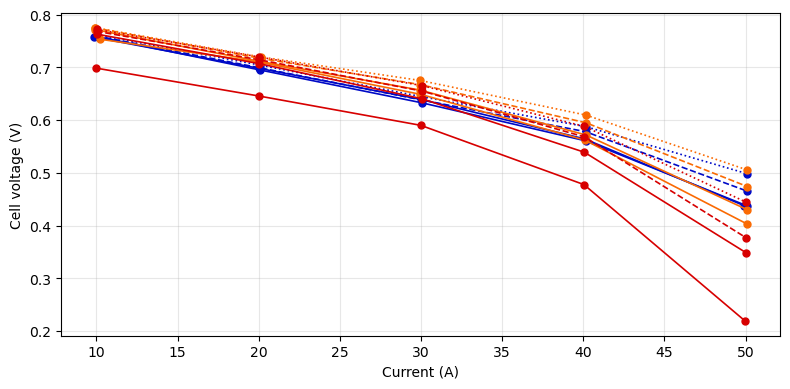

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
for name, data in polardata_exp.items():
    i_values = data["I_LOAD"].to_numpy(dtype=float)
    v_values = data["VFC"].to_numpy(dtype=float) / N_CELL_EXP
    idx_extracted = [np.argmin((i_test - i_values) ** 2) for i_test in I_tested]
    plot_condition(ax, i_values[idx_extracted], v_values[idx_extracted], name, linewidth=1.2, markersize=5)
ax.set_xlabel("Current (A)"); ax.set_ylabel("Cell voltage (V)"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Setup the simulation for all wanted conditions

In [6]:
def polartest_sim(params_trial, op_trial, cond_filter=None, lenient=False):
    """Run the 0D model across every (RHC, P, T) condition for which we have
    experimental data and return ``{cond_key: [Ucell at I_tested]}``.

    Two failure modes:
    - ``lenient=False`` (default, used by the optimizer): if *any* single
      condition fails to simulate cleanly, the whole sweep aborts and the
      function returns ``False``. The objective then penalises the trial.
    - ``lenient=True`` (used to build the post-calibration ``sim_all`` for
      plotting): a failed condition is skipped, the function keeps going and
      returns the partial dict of successful conditions. This way one bad
      condition no longer wipes the calibrated condition off the fit plot.

    Pass ``cond_filter(T, P, RHC) -> bool`` to restrict which conditions are
    simulated.
    """
    result = {}
    for RHC in RHC_tested:
        for P_des in PAC_tested:
            for T_des in TFC_tested:
                cond_key = "T" + str(T_des) + "_P" + str(int(P_des / 1e2 - 1e3)) + "_HRC" + str(RHC)
                if cond_key not in polardata_exp:
                    continue
                if cond_filter is not None and not cond_filter(T_des, P_des, RHC):
                    continue
                op = dict(op_trial)
                op["Phi_c_des"] = RHC / 100
                op["Pa_des"]    = P_des
                op["Pc_des"]    = P_des
                op["Tfc"]       = T_des + 273.15

                Ucell_test = []
                cond_failed = False
                for I_LOAD in I_tested:
                    i_density = I_LOAD / params_trial["Aact"]
                    op["current_density"] = lambda t, _i=i_density: _i
                    try:
                        model = PEMFC_0D(params_trial, op)
                        y0 = model.default_initial_state(params_trial, op)
                        info = model.solve(t_span=(0, 60), y0=y0, method="BDF",
                                           max_step=0.1, verbose=False, sparsity=False,
                                           atol=1e-8, rtol=1e-6)
                        sol = info["sol"]
                        if sol is None or not sol.success:
                            cond_failed = True
                            break
                        model._recovery(sol)
                        u = model.echem_traj["Ucell"][-1]
                        if not math.isfinite(u):
                            cond_failed = True
                            break
                        Ucell_test.append(u)
                    except Exception:
                        cond_failed = True
                        break

                if cond_failed:
                    if lenient:
                        continue   # skip this cond, keep sweeping
                    return False   # strict: abort the whole sweep
                result[cond_key] = Ucell_test
    return result

In [7]:
def _experimental_ucell(cond_key):
    """Experimental per-cell voltage at every I_tested for one condition."""
    df = polardata_exp[cond_key]
    i_exp = df["I_LOAD"].to_numpy(dtype=float)
    v_exp = df["VFC"].to_numpy(dtype=float) / N_CELL_EXP
    idx = [np.argmin((i_test - i_exp) ** 2) for i_test in I_tested]
    return v_exp[idx]


def make_objective(cond_filter):
    """Return an optuna objective that fits only the conditions selected by
    ``cond_filter`` -- so a single objective function can be reused across
    the calibration scenarios."""
    def objective(trial):
        params_trial = deepcopy(parameters)
        # Use a coarse Pt PSD grid for calibration speed -- PSD detail doesn't
        # affect the steady-state polar curve.
        params_trial["n_group_pt"] = 10
        op_trial = deepcopy(operating_inputs)

        params_trial["OCV"]         = trial.suggest_float("OCV",         0.9,   1.0,  log=True)
        params_trial["i0_c_ref"]    = trial.suggest_float("i0_c_ref",    1e-2,  10,   log=True)
        params_trial["kappa_c"]     = trial.suggest_float("kappa_c",     1,     10,   log=True)
        params_trial["tau"]         = trial.suggest_float("tau",         1,     4,    log=True)
        params_trial["Re"]          = trial.suggest_float("Re",          1e-7,  1e-5, log=True)
        params_trial["epsilon_mc"]  = trial.suggest_float("epsilon_mc",  0.15,  0.4,  log=True)
        params_trial["epsilon_gdl"] = trial.suggest_float("epsilon_gdl", 0.5,   0.7,  log=True)
        params_trial["epsilon_c"]   = trial.suggest_float("epsilon_c",   0.1,   0.3,  log=True)
        params_trial["epsilon_cl"]  = trial.suggest_float("epsilon_cl",  0.1,   0.4,  log=True)
        params_trial["Hcl"]         = trial.suggest_float("Hcl",         1e-5,  2e-5, log=True)
        params_trial["Hgdl"]        = trial.suggest_float("Hgdl",        2e-5,  5e-5, log=True)

        try:
            sim = polartest_sim(params_trial, op_trial, cond_filter=cond_filter)
        except Exception:
            return 100.0
        if sim is False or not sim:
            return 100.0

        error_sum = 0.0
        for cond_key, ucell_sim in sim.items():
            ucell_exp = _experimental_ucell(cond_key)
            error_sum += float(np.sum((np.array(ucell_sim) - ucell_exp) ** 2))
        return error_sum
    return objective

## Calibration scenarios
Compare the calibration result obtained when fitting the model against different subsets of the experimental polarization data.

In [8]:
SINGLE_T   = 60       # degrees C
SINGLE_P   = 1.4e5    # Pa
SINGLE_RHC = 50       # %
TWO_HUM_T  = 50       # degrees C
TWO_HUM_P  = 1.3e5    # Pa
FIXED_P    = 1.3e5    # Pa
FIXED_T    = 60       # degrees C

scenarios = {
    "one_condition":      {
        "label":  f"One condition (T={SINGLE_T}, P={SINGLE_P/1e5:.1f} bar, RHC={SINGLE_RHC})",
        "filter": lambda T, P, RHC: (T == SINGLE_T) and (P == SINGLE_P) and (RHC == SINGLE_RHC),
    },
    "two_humidification": {
        "label":  f"Two humidifications (P={TWO_HUM_P/1e5:.1f} bar, T={TWO_HUM_T}, RHC in {{0, 50}})",
        "filter": lambda T, P, RHC: (T == TWO_HUM_T) and (P == TWO_HUM_P) and (RHC in (0, 50)),
    },
    "fixed_pressure":     {
        "label":  f"Fixed pressure (P={FIXED_P/1e5:.1f} bar, all T, all RHC)",
        "filter": lambda T, P, RHC: P == FIXED_P,
    },
    "fixed_temperature":  {
        "label":  f"Fixed temperature (T={FIXED_T}, all P, all RHC)",
        "filter": lambda T, P, RHC: T == FIXED_T,
    },
    "all_data":           {
        "label":  "All conditions",
        "filter": lambda T, P, RHC: True,
    },
}


def conditions_in_scenario(filter_fn):
    keys = []
    for RHC in RHC_tested:
        for P_des in PAC_tested:
            for T_des in TFC_tested:
                cond_key = "T" + str(T_des) + "_P" + str(int(P_des/1e2 - 1e3)) + "_HRC" + str(RHC)
                exp_data = globals().get("polardata_exp") or globals().get("hfrdata_exp") or {}
                if cond_key in exp_data and filter_fn(T_des, P_des, RHC):
                    keys.append(cond_key)
    return keys


for name, info in scenarios.items():
    matches = conditions_in_scenario(info["filter"])
    print(f"  {name:20s}  {len(matches):2d} conditions  -> {matches}")

  one_condition          1 conditions  -> ['T60_P400_HRC50']
  two_humidification     2 conditions  -> ['T50_P300_HRC0', 'T50_P300_HRC50']
  fixed_pressure         6 conditions  -> ['T50_P300_HRC0', 'T60_P300_HRC0', 'T70_P300_HRC0', 'T50_P300_HRC50', 'T60_P300_HRC50', 'T70_P300_HRC50']
  fixed_temperature      4 conditions  -> ['T60_P300_HRC0', 'T60_P300_HRC50', 'T60_P400_HRC50', 'T60_P500_HRC50']
  all_data              12 conditions  -> ['T50_P300_HRC0', 'T60_P300_HRC0', 'T70_P300_HRC0', 'T50_P300_HRC50', 'T60_P300_HRC50', 'T70_P300_HRC50', 'T50_P400_HRC50', 'T60_P400_HRC50', 'T70_P400_HRC50', 'T50_P500_HRC50', 'T60_P500_HRC50', 'T70_P500_HRC50']


In [ ]:
# Run a separate optuna study per scenario. Each 0D trial does
# len(I_tested) short BDF integrations per condition -- with the
# Pukrushpan-style 31-state model, one trial is a few hundred ms.
optuna.logging.set_verbosity(optuna.logging.WARNING)

PER_SCENARIO_TIMEOUT = 300     # seconds
PER_SCENARIO_TRIALS  = 5000
N_JOBS               = 6

results = {}
for name, info in scenarios.items():
    print(f"\n=== Calibrating scenario: {name} ===")
    print(f"    {info['label']}")
    print(f"    conditions used: {conditions_in_scenario(info['filter'])}")
    study = optuna.create_study(direction="minimize")
    study.optimize(
        make_objective(info["filter"]),
        n_trials=PER_SCENARIO_TRIALS,
        timeout=PER_SCENARIO_TIMEOUT,
        n_jobs=N_JOBS,
        show_progress_bar=False,
    )

    # Re-run polartest_sim with the best params over ALL conditions so we can
    # later check how well each scenario generalises. Use lenient=True here so
    # that a single bad condition does not wipe the calibrated condition off
    # the fit plot.
    params_best = deepcopy(parameters)
    params_best["n_group_pt"] = 10
    op_best     = deepcopy(operating_inputs)
    params_best.update(study.best_params)
    sim_all     = polartest_sim(params_best, op_best, cond_filter=None, lenient=True)

    results[name] = {
        "label":           info["label"],
        "calibrated_keys": conditions_in_scenario(info["filter"]),
        "best_params":     study.best_params,
        "best_value":      study.best_value,
        "sim_all":         sim_all,
    }
    print(f"    best objective on the calibrated subset: {study.best_value:.4f}")
    n_ok = len(sim_all); n_total = len(polardata_exp)
    print(f"    sim_all covered {n_ok}/{n_total} conditions")


=== Calibrating scenario: one_condition ===
    One condition (T=60, P=1.4 bar, RHC=50)
    conditions used: ['T60_P400_HRC50']


## Best parameters side-by-side
How much do the calibrated parameters change as you broaden the training set? Big swings indicate the parameter is poorly constrained by the partial dataset.

In [ ]:
param_df = pd.DataFrame({name: info["best_params"] for name, info in results.items()})
print(param_df.to_string(float_format=lambda v: f"{v:.4g}"))

             one_condition  two_humidification  fixed_pressure  fixed_temperature  all_data
OCV                 0.9645              0.9857          0.9793             0.9005    0.9611
i0_c_ref              1.17             0.06733          0.0322             0.2324   0.08363
kappa_c              3.792               3.504           5.372               1.18     6.597
tau                   1.14               1.117           1.123              1.743      1.46
Re               2.168e-07           1.811e-07       8.296e-07          1.692e-06 1.569e-06
epsilon_mc          0.3995              0.1765          0.3109             0.1513    0.2289
epsilon_gdl         0.6364              0.5673          0.5491             0.5816    0.5102
epsilon_c           0.2276               0.186          0.1203             0.2489    0.1499
epsilon_cl          0.1253              0.3765          0.3468             0.2803    0.1224
Hcl              1.182e-05           1.598e-05       1.186e-05          1.769e-0

## Compare best-fit polarization curves across scenarios
`plot_scenario_fit(name)` produces two figures per scenario: the fit on the conditions used during calibration, then the fit on every experimental condition.

In [ ]:
def plot_scenario_fit(name):
    """For one calibration scenario, show two figures: the fit on the
    conditions used in the optimisation, then the fit on all conditions.
    Blue solid markers = experiment, red dotted squares = simulation.
    """
    info = results[name]
    cal_set = set(info["calibrated_keys"])

    panels_to_show = [
        ("USED for calibration", info["calibrated_keys"]),
        ("ALL conditions",       list(polardata_exp.keys())),
    ]
    for title_suffix, keys in panels_to_show:
        n = len(keys)
        if n == 0:
            print(f"({name}: no conditions for '{title_suffix}')")
            continue
        ncols = min(4, max(1, n))
        nrows = math.ceil(n / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.4 * nrows),
                                 sharex=True, sharey=True, squeeze=False)
        for ax, cond_key in zip(axes.flatten(), keys):
            ucell_exp = _experimental_ucell(cond_key)
            ucell_sim = info["sim_all"].get(cond_key)
            ax.plot(I_tested, ucell_exp, "o-", color="tab:blue",
                    linewidth=1.4, label="experiment")
            if ucell_sim is not None:
                ax.plot(I_tested, ucell_sim, "s:", color="tab:red",
                        linewidth=1.2, label="simulated")
            in_cal = cond_key in cal_set
            tag = "[CAL] " if in_cal else ""
            ax.set_title(f"{tag}{cond_key}", fontsize=8,
                         color="tab:green" if in_cal else "black")
            ax.grid(True, alpha=0.3)
        for ax in axes.flatten()[n:]:
            ax.set_visible(False)
        axes.flatten()[0].legend(fontsize=8, loc="best")
        fig.suptitle(f"{info['label']}  --  {title_suffix}\n"
                     f"objective on calibrated subset = {info['best_value']:.4f}",
                     fontsize=10)
        fig.tight_layout()
        plt.show()

### Scenario: `one_condition`

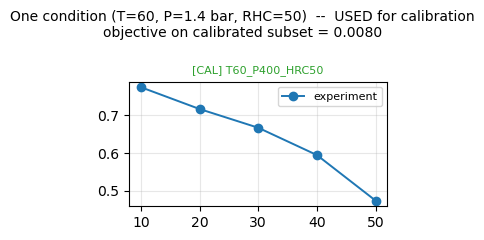

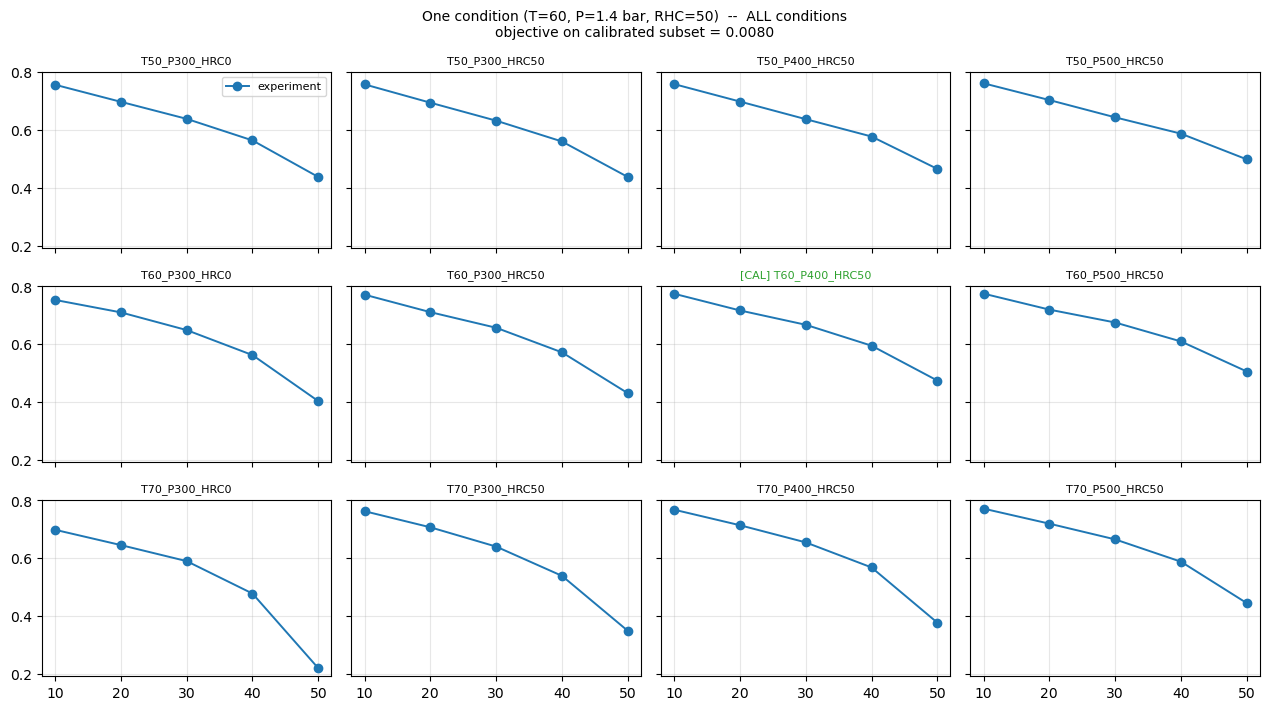

In [ ]:
plot_scenario_fit("one_condition")

### Scenario: `two_humidification`

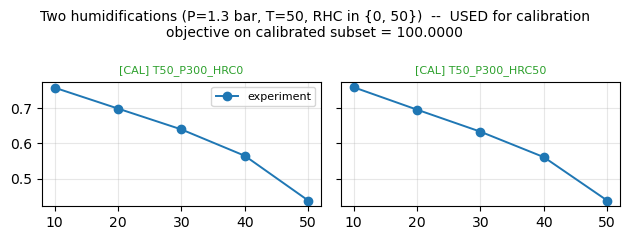

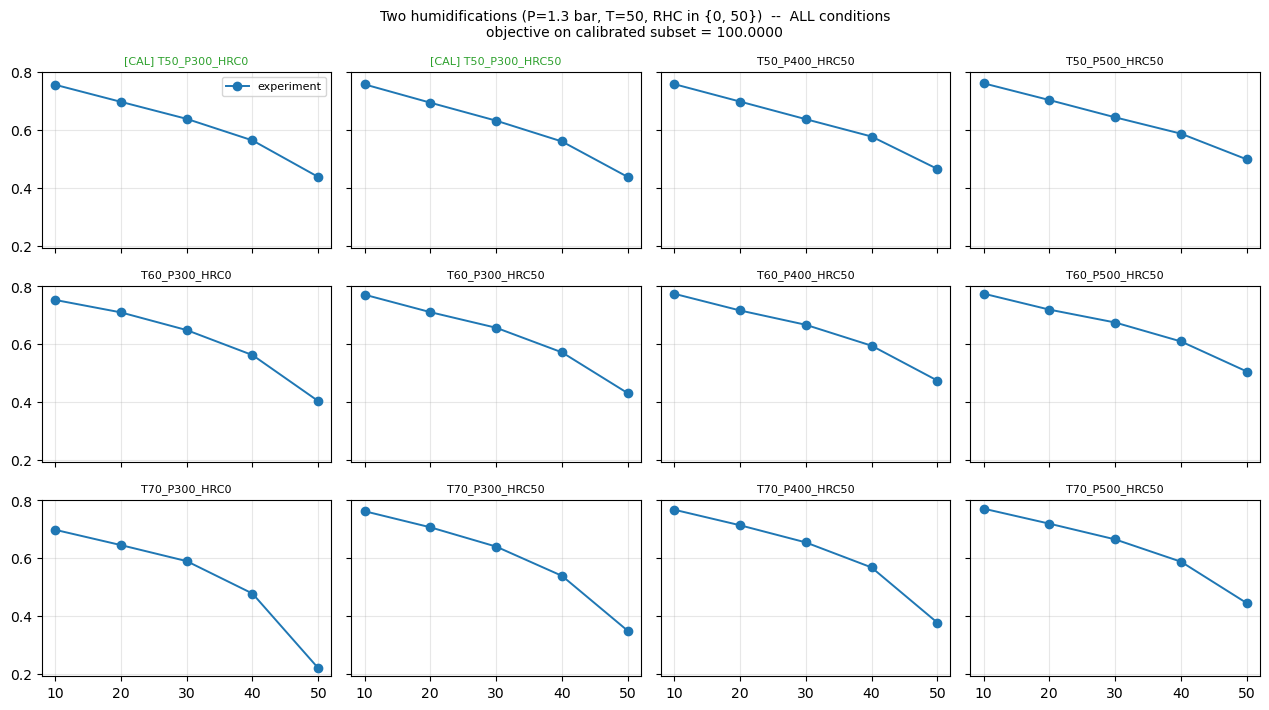

In [ ]:
plot_scenario_fit("two_humidification")

### Scenario: `fixed_pressure`

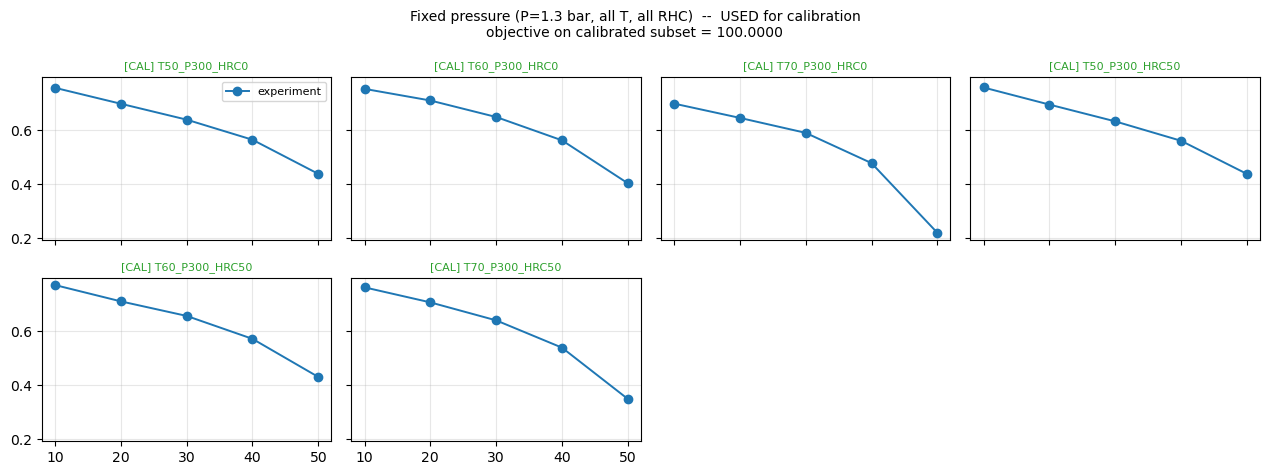

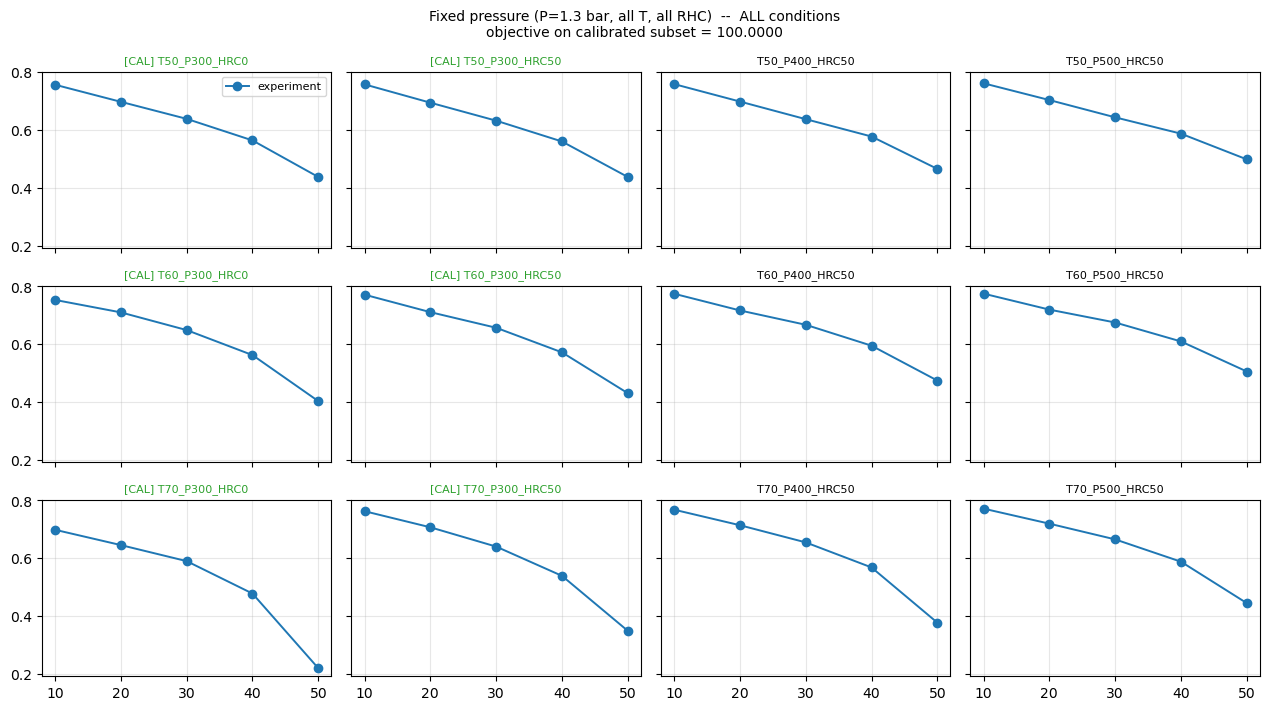

In [ ]:
plot_scenario_fit("fixed_pressure")

### Scenario: `fixed_temperature`

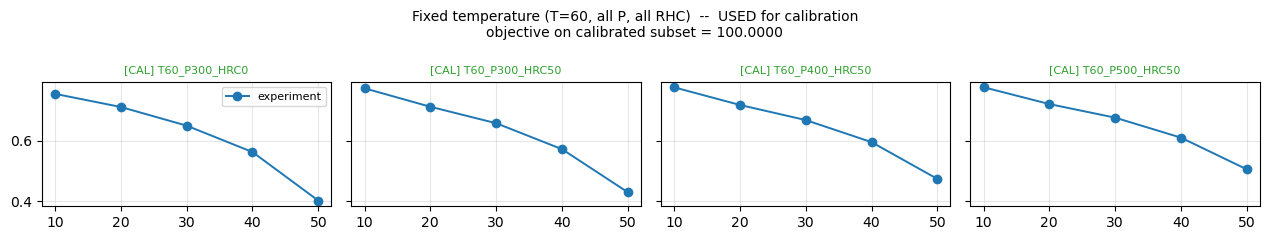

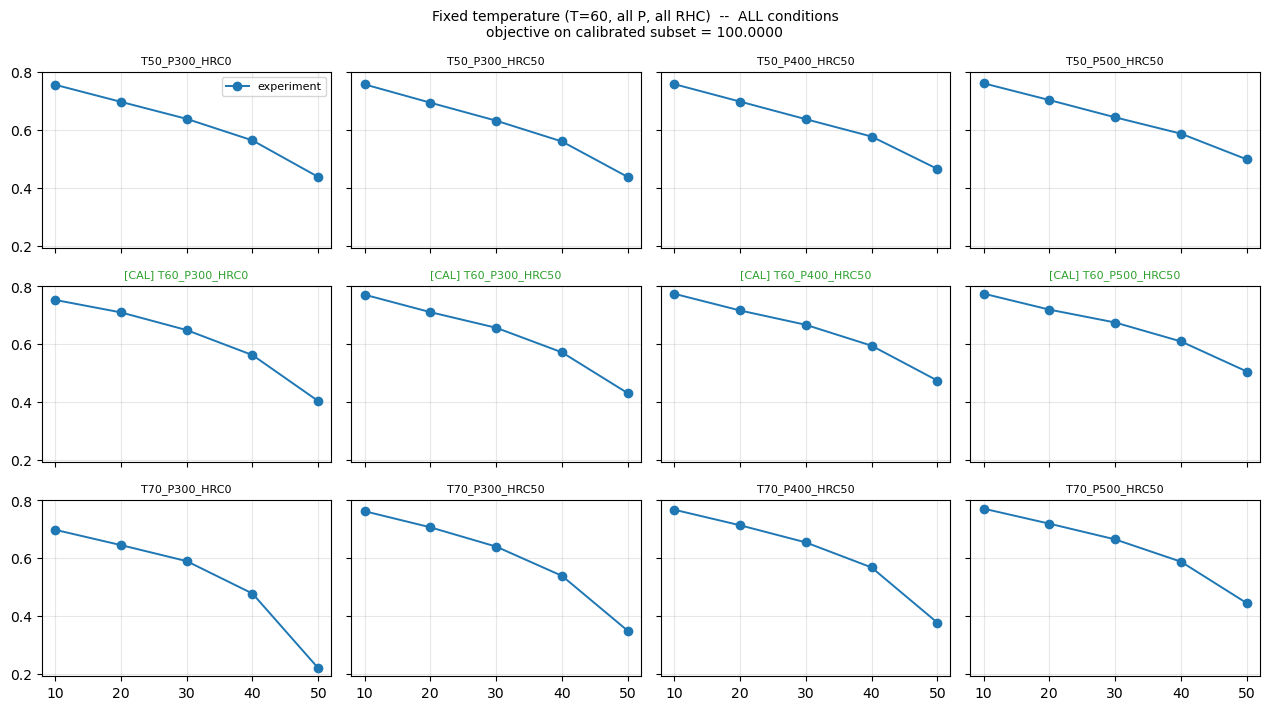

In [ ]:
plot_scenario_fit("fixed_temperature")

### Scenario: `all_data`

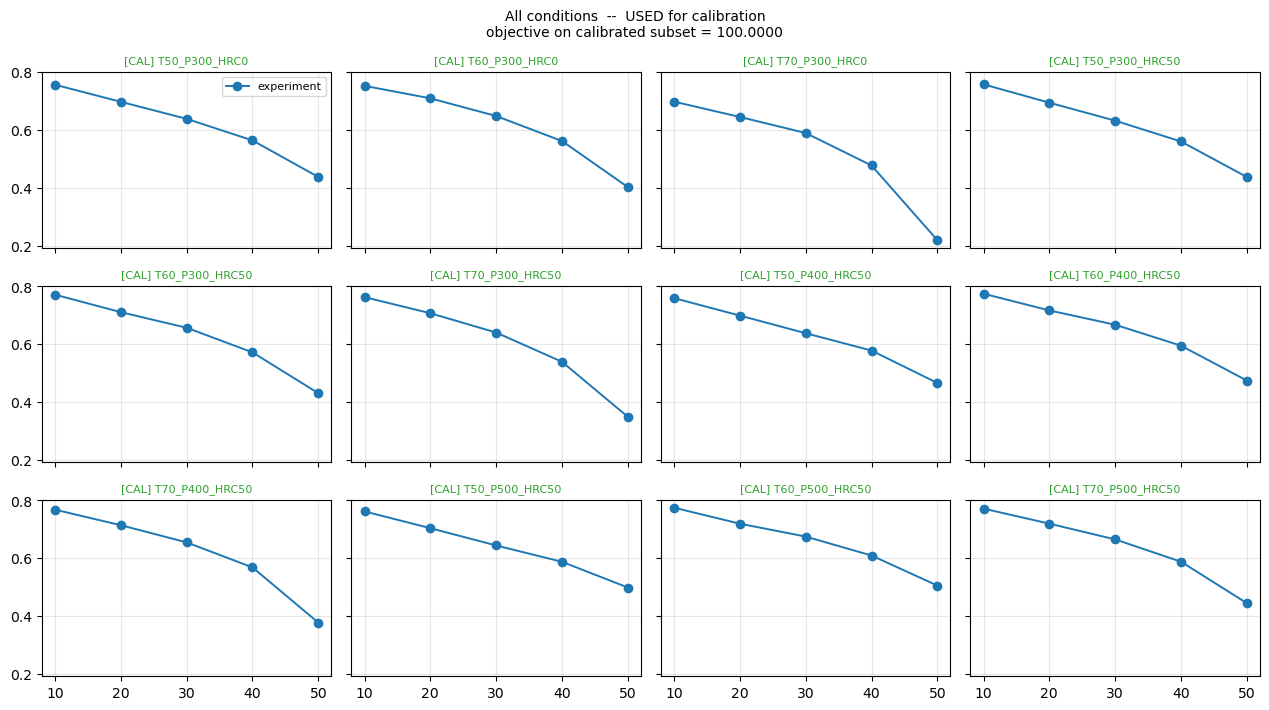

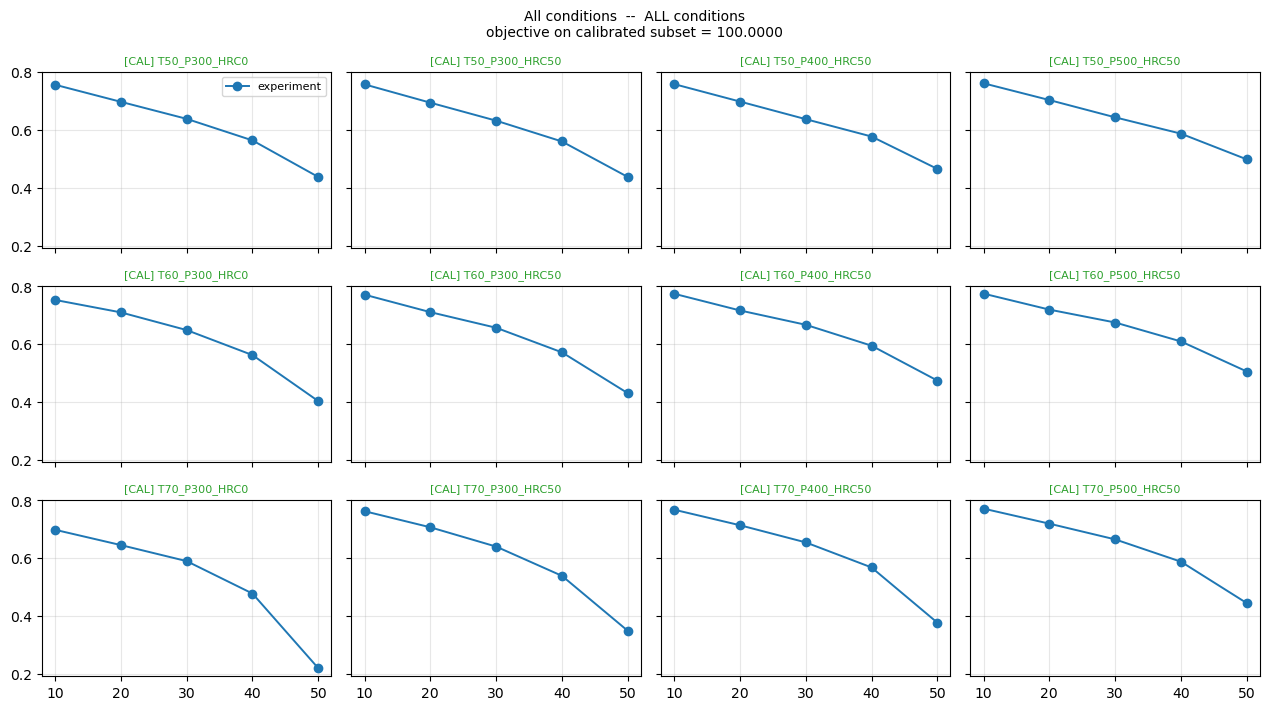

In [ ]:
plot_scenario_fit("all_data")

## Residual heatmap
Each row is a calibration scenario, each column an operating condition; the value is the sum of squared errors over the tested current points. Bright (low residual) on a column the scenario did NOT use during calibration tells you the scenario generalised; dark (large residual) tells you it did not.

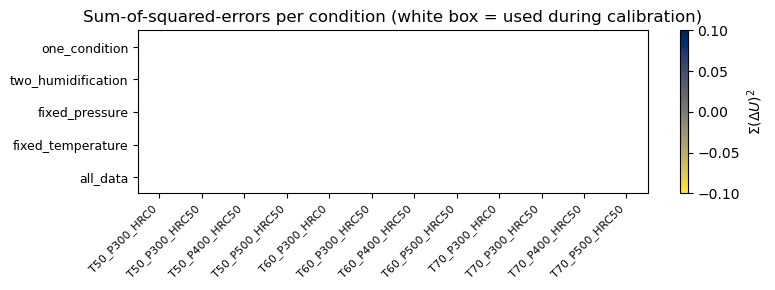

In [ ]:
all_cond_keys = list(polardata_exp.keys())
n_scen = len(results)
residual_matrix = np.full((n_scen, len(all_cond_keys)), np.nan)
for i_scen, (name, info) in enumerate(results.items()):
    for i_cond, cond_key in enumerate(all_cond_keys):
        if cond_key not in info["sim_all"]:
            continue
        ucell_sim = np.array(info["sim_all"][cond_key])
        ucell_exp = _experimental_ucell(cond_key)
        residual_matrix[i_scen, i_cond] = float(np.sum((ucell_sim - ucell_exp) ** 2))

fig, ax = plt.subplots(figsize=(max(8, len(all_cond_keys) * 0.5), 0.5 + 0.5 * n_scen))
im = ax.imshow(residual_matrix, aspect="auto", cmap="cividis_r")
ax.set_yticks(range(n_scen)); ax.set_yticklabels(list(results.keys()), fontsize=9)
ax.set_xticks(range(len(all_cond_keys)))
ax.set_xticklabels(all_cond_keys, rotation=45, ha="right", fontsize=8)
for i_scen, (name, info) in enumerate(results.items()):
    cal_set = set(info["calibrated_keys"])
    for i_cond, cond_key in enumerate(all_cond_keys):
        if cond_key in cal_set:
            ax.add_patch(plt.Rectangle((i_cond - 0.5, i_scen - 0.5), 1, 1,
                                       fill=False, edgecolor="white", linewidth=2))
ax.set_title("Sum-of-squared-errors per condition (white box = used during calibration)")
fig.colorbar(im, ax=ax, label=r"$\Sigma(\Delta U)^2$")
plt.tight_layout(); plt.show()